# Notebook 01 — Preparación del Dataset SEM
## Clasificación Binaria: Nanopartículas (0D) vs Nanohilos (1D)

**Dataset:** [NFFA-EUROPE SEM Dataset](https://b2share.eudat.eu/records/qtq9v-ys023)  
**Categorías:** `Particles` (0D) y `Nanowires` (1D)  
**Referencia:** Modarres et al., Scientific Reports 7, 13282 (2017)

---

## Contenido
1. Descarga del dataset desde NFFA-EUROPE
2. Exploración y estadísticas
3. Preprocessing (resize, normalización)
4. Data augmentation
5. Split train/val/test (70/15/15)
6. Verificación del DataLoader de PyTorch

In [1]:
# ============================================================
# WARM-UP: Verificar dependencias
# ============================================================
import subprocess, sys

REQUIRED = ['torch', 'torchvision', 'PIL', 'matplotlib', 'numpy', 'tqdm']
for pkg in REQUIRED:
    try:
        __import__(pkg)
        print(f'  OK: {pkg}')
    except ImportError:
        pip_name = 'Pillow' if pkg == 'PIL' else pkg
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pip_name, '-q'])
        print(f'  Instalado: {pip_name}')

import torch
print(f'\nPyTorch {torch.__version__}')
print(f'CUDA disponible: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print('\nWarm-up completado.')

  OK: torch
  OK: torchvision
  OK: PIL
  OK: matplotlib
  OK: numpy
  OK: tqdm

PyTorch 2.11.0+cu128
CUDA disponible: True
GPU: NVIDIA GeForce RTX 5050 Laptop GPU

Warm-up completado.


## 1. Descarga del Dataset

Descargamos las categorías `Particles.tar` y `Nanowires.tar` del NFFA-EUROPE SEM Dataset.  
El dataset completo tiene 18,577 imágenes SEM en 10 categorías; solo usamos 2 para clasificación binaria.

> **Nota:** La descarga puede tomar varios minutos dependiendo de la velocidad de conexión. El script soporta resumen automático si se interrumpe.

In [2]:
# ============================================================
# DESCARGA DEL DATASET NFFA-EUROPE SEM
# ============================================================
import os
import urllib.request
import tarfile
from pathlib import Path
from tqdm import tqdm

# Directorios
PROJECT_ROOT = Path('..').resolve()
DATA_RAW = PROJECT_ROOT / 'data' / 'raw'
DATA_RAW.mkdir(parents=True, exist_ok=True)

BASE_URL = 'https://b2share.eudat.eu/records/qtq9v-ys023/files'

CATEGORIES = {
    'Particles': f'{BASE_URL}/Particles.tar?download=1',
    'Nanowires': f'{BASE_URL}/Nanowires.tar?download=1',
}

class DownloadProgressBar(tqdm):
    def update_to(self, b=1, bsize=1, tsize=None):
        if tsize is not None:
            self.total = tsize
        self.update(b * bsize - self.n)

for name, url in CATEGORIES.items():
    tar_path = DATA_RAW / f'{name}.tar'
    extract_dir = DATA_RAW / name
    
    # Skip si ya extraído
    if extract_dir.exists() and any(extract_dir.iterdir()):
        print(f'✓ {name}/ ya existe ({len(list(extract_dir.rglob("*.tif"))) + len(list(extract_dir.rglob("*.png"))) + len(list(extract_dir.rglob("*.jpg")))} imágenes)')
        continue
    
    # Descargar
    if not tar_path.exists():
        print(f'Descargando {name}.tar...')
        with DownloadProgressBar(unit='B', unit_scale=True, miniters=1, desc=name) as t:
            urllib.request.urlretrieve(url, tar_path, reporthook=t.update_to)
        print(f'  Descargado: {tar_path.stat().st_size / 1024**2:.1f} MB')
    
    # Extraer
    print(f'Extrayendo {name}.tar...')
    with tarfile.open(tar_path, 'r') as tar:
        tar.extractall(path=DATA_RAW)
    print(f'  Extraído en: {extract_dir}')

print('\nDescarga completa.')

✓ Particles/ ya existe (37 imágenes)
✓ Nanowires/ ya existe (657 imágenes)

Descarga completa.


## 2. Exploración del Dataset

In [3]:
# ============================================================
# EXPLORACIÓN: Conteo y estadísticas de imágenes
# ============================================================
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

IMG_EXTS = {'.tif', '.tiff', '.png', '.jpg', '.jpeg', '.bmp'}

stats = {}
for name in CATEGORIES:
    cat_dir = DATA_RAW / name
    images = [f for f in cat_dir.rglob('*') if f.suffix.lower() in IMG_EXTS]
    
    # Muestrear resoluciones
    widths, heights = [], []
    for img_path in images[:100]:  # muestra de 100
        try:
            with Image.open(img_path) as im:
                w, h = im.size
                widths.append(w)
                heights.append(h)
        except Exception:
            pass
    
    stats[name] = {
        'count': len(images),
        'avg_width': np.mean(widths) if widths else 0,
        'avg_height': np.mean(heights) if heights else 0,
        'min_res': f'{min(widths, default=0)}x{min(heights, default=0)}',
        'max_res': f'{max(widths, default=0)}x{max(heights, default=0)}',
    }
    
    label = '0D (Nanopartículas)' if name == 'Particles' else '1D (Nanohilos)'
    print(f'\n{label} — {name}/')
    print(f'  Imágenes: {stats[name]["count"]}')
    print(f'  Resolución promedio: {stats[name]["avg_width"]:.0f} x {stats[name]["avg_height"]:.0f}')
    print(f'  Rango: {stats[name]["min_res"]} — {stats[name]["max_res"]}')


0D (Nanopartículas) — Particles/
  Imágenes: 37
  Resolución promedio: 1079 x 810
  Rango: 1024x768 — 3072x2304

1D (Nanohilos) — Nanowires/
  Imágenes: 657
  Resolución promedio: 1024 x 768
  Rango: 1024x768 — 1024x768


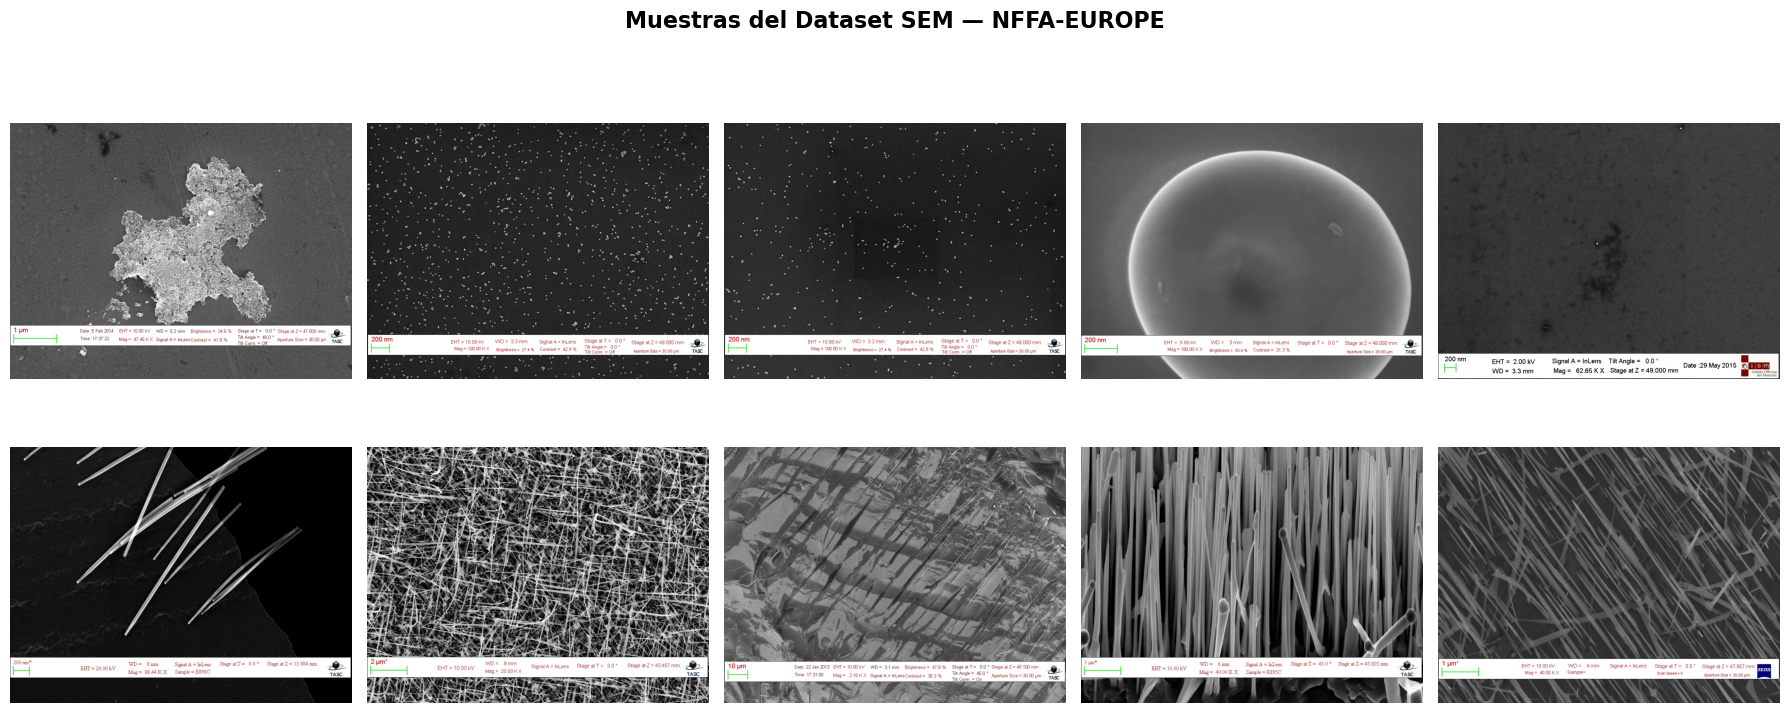

Figura guardada en reports/dataset_samples.png


In [4]:
# ============================================================
# VISUALIZACIÓN: Muestras de cada clase
# ============================================================
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for row, name in enumerate(CATEGORIES):
    cat_dir = DATA_RAW / name
    images = sorted([f for f in cat_dir.rglob('*') if f.suffix.lower() in IMG_EXTS])[:5]
    label = '0D Nanopartículas' if name == 'Particles' else '1D Nanohilos'
    
    for col, img_path in enumerate(images):
        ax = axes[row, col]
        try:
            img = Image.open(img_path).convert('RGB')
            ax.imshow(img)
        except Exception:
            ax.text(0.5, 0.5, 'Error', ha='center', va='center')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(label, fontsize=14, fontweight='bold')

plt.suptitle('Muestras del Dataset SEM — NFFA-EUROPE', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'reports' / 'dataset_samples.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada en reports/dataset_samples.png')

## 3. Preprocessing y Split

Preprocesamos las imágenes:
- **Resize** a 224×224 (compatible con ResNet)
- Conversión a RGB
- **Split** 70/15/15 estratificado en train/val/test
- Organización en estructura `ImageFolder` de PyTorch

In [5]:
# ============================================================
# PREPROCESSING: Resize + Split train/val/test
# ============================================================
import shutil
import random

random.seed(42)

DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
TARGET_SIZE = (224, 224)
SPLITS = {'train': 0.70, 'val': 0.15, 'test': 0.15}

CLASS_MAP = {
    'Particles': 'nanoparticles',   # 0D
    'Nanowires': 'nanowires',       # 1D
}

for orig_name, class_name in CLASS_MAP.items():
    cat_dir = DATA_RAW / orig_name
    all_images = sorted([f for f in cat_dir.rglob('*') if f.suffix.lower() in IMG_EXTS])
    random.shuffle(all_images)
    
    n = len(all_images)
    n_train = int(n * SPLITS['train'])
    n_val = int(n * SPLITS['val'])
    
    split_map = {
        'train': all_images[:n_train],
        'val':   all_images[n_train:n_train + n_val],
        'test':  all_images[n_train + n_val:],
    }
    
    for split_name, image_list in split_map.items():
        out_dir = DATA_PROCESSED / split_name / class_name
        out_dir.mkdir(parents=True, exist_ok=True)
        
        count = 0
        for img_path in tqdm(image_list, desc=f'{class_name}/{split_name}', leave=False):
            try:
                img = Image.open(img_path).convert('RGB')
                img = img.resize(TARGET_SIZE, Image.LANCZOS)
                out_path = out_dir / f'{class_name}_{count:04d}.png'
                img.save(out_path)
                count += 1
            except Exception as e:
                pass  # Skip corrupt images
        
        print(f'  {class_name}/{split_name}: {count} imágenes')

print('\nPreprocessing completo.')

  nanoparticles/train: 24 imágenes


  nanoparticles/val: 5 imágenes


  nanoparticles/test: 7 imágenes


  nanowires/train: 458 imágenes


  nanowires/val: 98 imágenes


  nanowires/test: 100 imágenes

Preprocessing completo.


In [6]:
# ============================================================
# RESUMEN del split
# ============================================================
print('Distribución del dataset procesado:')
print('=' * 50)
total = 0
for split in ['train', 'val', 'test']:
    split_dir = DATA_PROCESSED / split
    for cls_dir in sorted(split_dir.iterdir()):
        if cls_dir.is_dir():
            n = len(list(cls_dir.glob('*.png')))
            total += n
            print(f'  {split:5s} / {cls_dir.name:15s}: {n:5d} imágenes')

print(f'\nTotal: {total} imágenes procesadas (224×224 RGB)')

Distribución del dataset procesado:
  train / nanoparticles  :    24 imágenes
  train / nanowires      :   458 imágenes
  val   / nanoparticles  :     5 imágenes
  val   / nanowires      :    98 imágenes
  test  / nanoparticles  :     7 imágenes
  test  / nanowires      :   100 imágenes

Total: 692 imágenes procesadas (224×224 RGB)


## 4. Data Augmentation y DataLoader PyTorch

Definimos las transformaciones para entrenamiento (con augmentation) y evaluación (sin augmentation).

In [7]:
# ============================================================
# DATALOADERS: PyTorch ImageFolder + Transforms
# ============================================================
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Normalización ImageNet (standard para transfer learning)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Transforms para entrenamiento (con data augmentation)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Transforms para validación y test (sin augmentation)
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Crear datasets
train_dataset = datasets.ImageFolder(str(DATA_PROCESSED / 'train'), transform=train_transform)
val_dataset   = datasets.ImageFolder(str(DATA_PROCESSED / 'val'),   transform=eval_transform)
test_dataset  = datasets.ImageFolder(str(DATA_PROCESSED / 'test'),  transform=eval_transform)

# DataLoaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Clases: {train_dataset.classes}')
print(f'Mapeo:  {train_dataset.class_to_idx}')
print(f'\nTrain: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')
print(f'Batches: Train={len(train_loader)} | Val={len(val_loader)} | Test={len(test_loader)}')

Clases: ['nanoparticles', 'nanowires']
Mapeo:  {'nanoparticles': 0, 'nanowires': 1}

Train: 482 | Val: 103 | Test: 107
Batches: Train=16 | Val=4 | Test=4


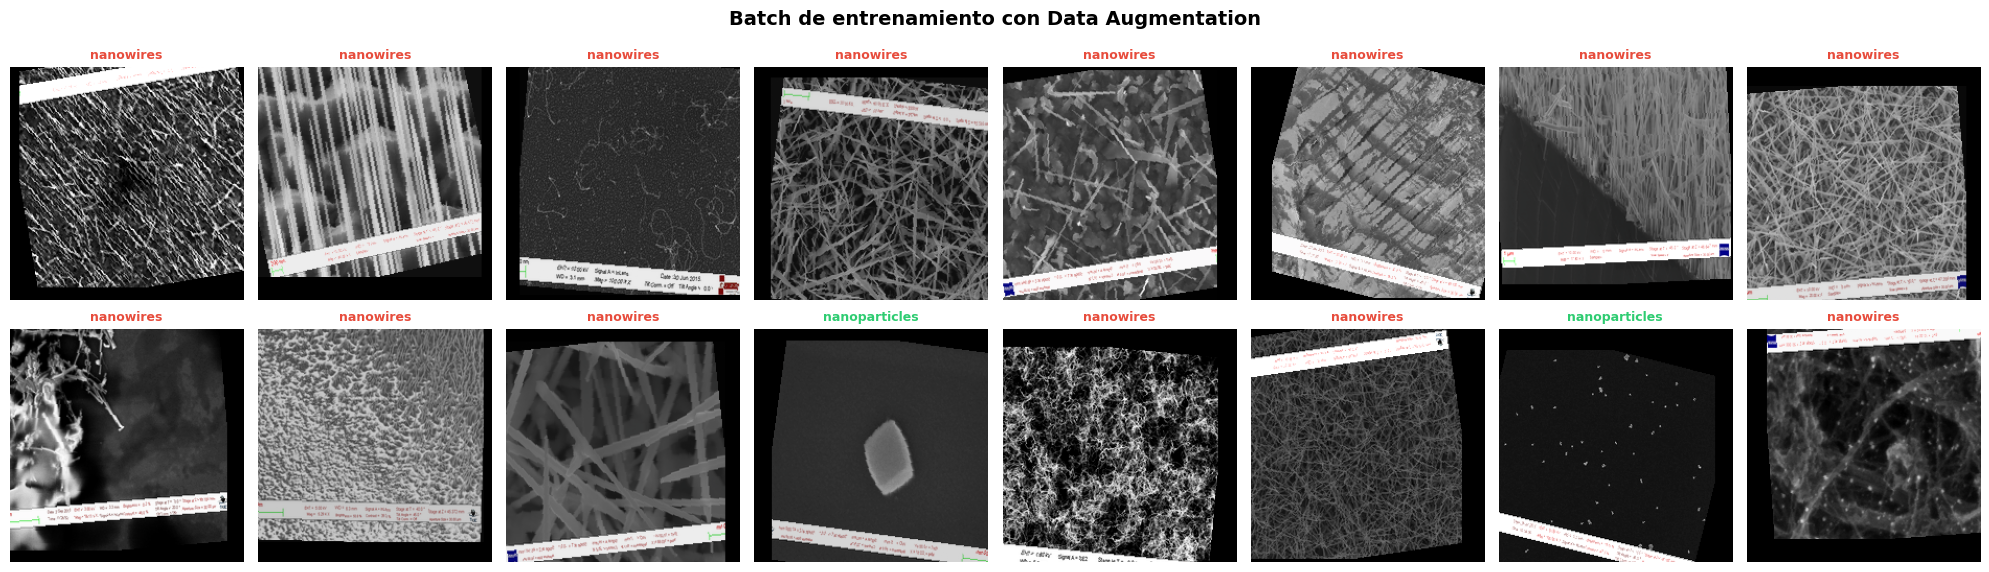


Shape del batch: torch.Size([32, 3, 224, 224])
Labels: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1]

✓ DataLoaders listos para entrenamiento.


In [8]:
# ============================================================
# VISUALIZACIÓN: Batch con augmentation aplicado
# ============================================================
def denormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """Desnormaliza un tensor para visualización."""
    t = tensor.clone()
    for c, m, s in zip(t, mean, std):
        c.mul_(s).add_(m)
    return t.clamp(0, 1)

# Obtener un batch
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
for i, ax in enumerate(axes.flat):
    if i < len(images):
        img = denormalize(images[i]).permute(1, 2, 0).numpy()
        ax.imshow(img)
        label = train_dataset.classes[labels[i]]
        color = '#2ecc71' if label == 'nanoparticles' else '#e74c3c'
        ax.set_title(label, fontsize=9, color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle('Batch de entrenamiento con Data Augmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nShape del batch: {images.shape}')
print(f'Labels: {labels[:16].tolist()}')
print(f'\n✓ DataLoaders listos para entrenamiento.')

## 5. Guardar configuración para los siguientes notebooks

In [9]:
# ============================================================
# GUARDAR CONFIGURACIÓN del dataset
# ============================================================
import json

dataset_config = {
    'project_root': str(PROJECT_ROOT),
    'data_processed': str(DATA_PROCESSED),
    'classes': train_dataset.classes,
    'class_to_idx': train_dataset.class_to_idx,
    'n_train': len(train_dataset),
    'n_val': len(val_dataset),
    'n_test': len(test_dataset),
    'image_size': 224,
    'batch_size': BATCH_SIZE,
    'imagenet_mean': IMAGENET_MEAN,
    'imagenet_std': IMAGENET_STD,
    'source': 'NFFA-EUROPE SEM Dataset (b2share.eudat.eu)',
    'doi': '10.1038/s41598-017-13565-z',
}

config_path = PROJECT_ROOT / 'reports' / 'dataset_config.json'
with open(config_path, 'w') as f:
    json.dump(dataset_config, f, indent=2)

print(f'Configuración guardada en: {config_path}')
print(f'\n→ Continuar con: 02_model_training.ipynb')

Configuración guardada en: C:\IA Nanotecnología\Antigravity-Nano-Research-Multiagentic-Core-main\educational_content\Proyecto final\reports\dataset_config.json

→ Continuar con: 02_model_training.ipynb
